In [3]:
from pathlib import Path
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import gcamp_peak_utils as gp

In [2]:
def load_peak_stats_for_cell(stats_path, cell_name, usecols=None, chunksize=50000):
    """
    Load only rows for one cell from a large peak-stats CSV.

    Parameters
    ----------
    stats_path : str or Path
    cell_name : str
        Example: "cell_3"
    usecols : list or None
        Columns to load. If None, loads all columns.
    chunksize : int
        Number of rows per chunk.

    Returns
    -------
    pd.DataFrame
    """
    stats_path = Path(stats_path)

    if usecols is not None and "cell" not in usecols:
        usecols = ["cell"] + list(usecols)

    chunks = []
    for chunk in pd.read_csv(stats_path, usecols=usecols, chunksize=chunksize, low_memory=False):
        sub = chunk.loc[chunk["cell"] == cell_name]
        if not sub.empty:
            chunks.append(sub)

    if not chunks:
        return pd.DataFrame(columns=usecols if usecols is not None else None)

    return pd.concat(chunks, ignore_index=True)

def list_cells_in_peak_stats(stats_path, chunksize=50000):
    seen = set()
    for chunk in pd.read_csv(stats_path, usecols=["cell"], chunksize=chunksize):
        seen.update(chunk["cell"].dropna().unique())

    def natural_cell_key(name):
        m = re.match(r"cell_(\d+)$", str(name))
        if m:
            return (0, int(m.group(1)))
        return (1, str(name))

    return sorted(seen, key=natural_cell_key)




In [3]:
# for loading ActSort labels 
def cell_name_to_matlab_idx(cell_name):
    m = re.fullmatch(r"cell_(\d+)", str(cell_name))
    if m is None:
        raise ValueError(f"Could not parse cell name: {cell_name}")
    return int(m.group(1))  # MATLAB-style cell number, e.g. cell_1 -> 1

def is_good_cell(cell_name, labels_overall):
    matlab_idx = cell_name_to_matlab_idx(cell_name)
    python_idx = matlab_idx - 1  # convert MATLAB 1-indexing to Python 0-indexing
    if python_idx < 0 or python_idx >= len(labels_overall):
        return False
    return labels_overall[python_idx] == 1

In [4]:
##path to dataframe 
stats_path = Path("/scratch/jma819/CaliAli_linearTrackData/m311_analysis/all_peak_stats_20260518_211705.csv")

#matching full Ca2+ traces for full length of traces 
csv_path = Path("/scratch/jma819/CaliAli_linearTrackData/m311_analysis/GCAMP_with_velocity.csv")
with csv_path.open("r") as f:
    n_rows = sum(1 for _ in f) - 1  # subtract header


In [5]:
#preview only a few rows 
preview_df = pd.read_csv(stats_path, nrows=10)
preview_df

,cell,event_id,peak_idx,onset_idx,offset_idx,amp_max,length_samples,clip_start,clip_end
0,cell_0,0,644,0,271419,20.055775,271419,0,271419
1,cell_0,1,1688,1534,2637,4.570475,1103,1524,2647
2,cell_0,2,1725,1534,2637,4.570475,1103,1524,2647
3,cell_0,3,2321,1534,2637,4.570475,1103,1524,2647
4,cell_0,4,5261,4428,5909,4.352701,1481,4418,5919
5,cell_0,5,5888,4428,5909,4.352701,1481,4418,5919
6,cell_0,6,6492,6119,271419,20.055775,265300,6109,271419
7,cell_0,7,9041,8777,61581,12.844885,52804,8767,61591
8,cell_0,8,15285,15134,17621,5.859591,2487,15124,17631
9,cell_0,9,19389,19051,21258,7.784964,2207,19041,21268


In [6]:
#list cells in recording
cells = list_cells_in_peak_stats(stats_path)
cells[:20]

['cell_0',
 'cell_1',
 'cell_2',
 'cell_3',
 'cell_4',
 'cell_5',
 'cell_6',
 'cell_7',
 'cell_8',
 'cell_9',
 'cell_11',
 'cell_12',
 'cell_13',
 'cell_14',
 'cell_15',
 'cell_16',
 'cell_17',
 'cell_18',
 'cell_19',
 'cell_20']

In [9]:
# load one cell 
cell_stats_df = load_peak_stats_for_cell(stats_path, cell_name="cell_20")


In [10]:
cell_stats_df

,cell,event_id,peak_idx,onset_idx,offset_idx,amp_max,length_samples,clip_start,clip_end
0,cell_20,0,139,0,271419,20.858742,271419,0,271419
1,cell_20,1,1535,1530,13943,6.984809,12413,1520,13953
2,cell_20,2,2518,1686,2764,6.446059,1078,1676,2774
3,cell_20,3,2678,1686,2764,6.446059,1078,1676,2774
4,cell_20,4,3654,3074,4916,5.655992,1842,3064,4926
...,...,...,...,...,...,...,...,...,...
357,cell_20,357,267580,267528,267626,5.646795,98,267518,267636
358,cell_20,358,268823,268422,270389,5.614809,1967,268412,270399
359,cell_20,359,268933,268422,270389,5.614809,1967,268412,270399
360,cell_20,360,269163,269083,269241,5.421927,158,269073,269251


In [11]:
cell_stats_df.onset_idx

0           0
1        1530
2        1686
3        1686
4        3074
        ...  
357    267528
358    268422
359    268422
360    269083
361    269239
Name: onset_idx, Length: 362, dtype: int64

In [12]:
n_rows

271420

In [13]:
# calculate "eventsPerSecond" as whether a "onset_idx" is within a moving 1 second window 
window_len = 20
onset_counts = np.bincount(cell_stats_df["onset_idx"].to_numpy(), minlength=n_rows)
eventsPerSecond_convolve = np.convolve(onset_counts, np.ones(window_len, dtype=int), mode="valid")


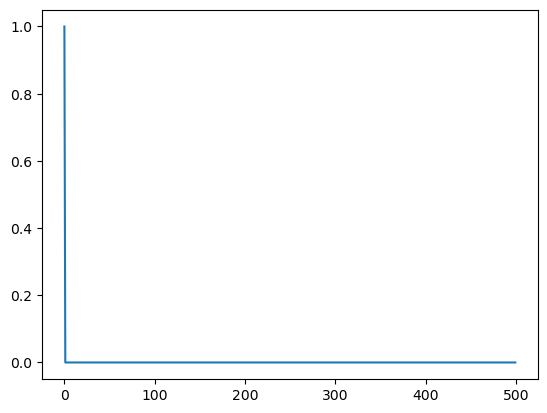

In [14]:
plt.plot(eventsPerSecond_convolve[0:500])

In [31]:
# refilter cells using ActSort labels 
labels_path = Path("/scratch/jma819/CaliAli_linearTrackData/m989_analysis/precomputed_output_LABELS.mat")
mat = sio.loadmat(labels_path, squeeze_me=True, struct_as_record=False)
labels = mat["labels"]
labels_ex = np.asarray(labels.labels_ex).squeeze().astype(int)
labels_ml = np.asarray(labels.labels_ml).squeeze().astype(int)
labels_overall = np.asarray(labels.labels_overall).squeeze().astype(int)
# get good cells 
cells = list_cells_in_peak_stats(stats_path)
good_cells = [cell for cell in cells if is_good_cell(cell, labels_overall)]
len(good_cells)

488

In [17]:
#or if no filter 
good_cells = cells

In [18]:
# calculate "eventsPerSecond" as whether a "onset_idx" is within a moving 1 second window for all cells 
cells = list_cells_in_peak_stats(stats_path)
events_per_second_dict = {}
for cell in cells:
    print(cell)
    cell_stats_df = load_peak_stats_for_cell(stats_path, cell_name=cell)
    # calculate "eventsPerSecond" as whether a "onset_idx" is within a moving 1 second window 
    window_len = 20
    onset_counts = np.bincount(cell_stats_df["onset_idx"].to_numpy(), minlength=n_rows)
    eventsPerSecond_convolve = np.convolve(onset_counts, np.ones(window_len, dtype=int), mode="valid")
    events_per_second_dict[cell] = eventsPerSecond_convolve

cell_0
cell_1
cell_2
cell_3
cell_4
cell_5
cell_6
cell_7
cell_8
cell_9
cell_11
cell_12
cell_13
cell_14
cell_15
cell_16
cell_17
cell_18
cell_19
cell_20
cell_21
cell_22
cell_23
cell_24
cell_25
cell_26
cell_27
cell_28
cell_30
cell_31
cell_32
cell_33
cell_34
cell_35
cell_36
cell_37
cell_38
cell_39
cell_40
cell_41
cell_42
cell_43
cell_45
cell_46
cell_47
cell_48
cell_49
cell_50
cell_51
cell_52
cell_53
cell_54
cell_55
cell_56
cell_57
cell_58
cell_59
cell_60
cell_61
cell_62
cell_63
cell_64
cell_65
cell_66
cell_67
cell_68
cell_69
cell_70
cell_71
cell_72
cell_73
cell_74
cell_76
cell_77
cell_78
cell_79
cell_80
cell_81
cell_82
cell_83
cell_84
cell_87
cell_88
cell_89
cell_90
cell_91
cell_92
cell_93
cell_94
cell_95
cell_96
cell_97
cell_98
cell_99
cell_100
cell_101
cell_102
cell_103
cell_104
cell_105
cell_106
cell_107
cell_108
cell_109
cell_110
cell_111
cell_112
cell_113
cell_114
cell_116
cell_117
cell_118
cell_121
cell_122
cell_123
cell_124
cell_125
cell_126
cell_127
cell_128
cell_129
cell_130
cell_1

In [19]:
eventsPerSecond_df = pd.DataFrame(events_per_second_dict)

In [20]:
eventsPerSecond_df.mean(axis=0)

cell_0      0.033607
cell_1      0.027119
cell_2      0.048342
cell_3      0.021223
cell_4      0.028821
              ...   
cell_712    0.029267
cell_713    0.025497
cell_714    0.010243
cell_716    0.018202
cell_717    0.008180
Length: 656, dtype: float64

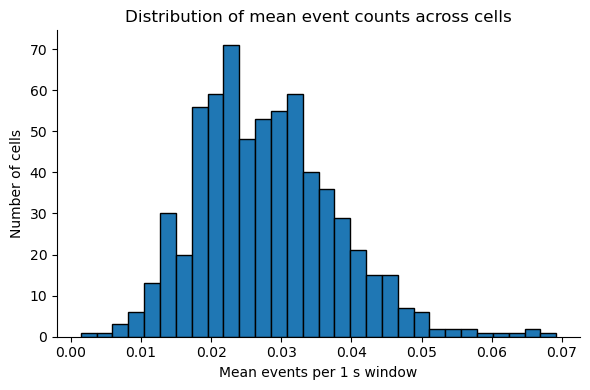

In [21]:
# histogram of firing rate across all cells
import matplotlib.pyplot as plt

mean_events_per_cell = eventsPerSecond_df.mean(axis=0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(mean_events_per_cell, bins=30, edgecolor="black")
ax.set_xlabel("Mean events per 1 s window")
ax.set_ylabel("Number of cells")
ax.set_title("Distribution of mean event counts across cells")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [22]:
save_path = Path("/scratch/jma819/CaliAli_linearTrackData/m311_analysis/eventsPerSecond_df.csv")
eventsPerSecond_df.to_csv(save_path, index=True)

print(save_path)

/scratch/jma819/CaliAli_linearTrackData/m311_analysis/eventsPerSecond_df.csv
